In [29]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [31]:
y=df['diabetes']


In [32]:
x=df.drop('diabetes',axis=1)


In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=100)


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
lr=LinearRegression()
lr.fit(x_train,y_train)
y_lr_train_pred=lr.predict(x_train)
y_lr_test_pred=lr.predict(x_test)
rf=RandomForestClassifier(max_depth=2,random_state=100)
rf.fit(x_train,y_train)
y_rf_train_pred=rf.predict(x_train)
y_rf_test_pred=rf.predict(x_test)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=100
)
xgb.fit(x_train, y_train)
y_xgb_pred = xgb.predict(x_test)
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=100
)

dt.fit(x_train, y_train)
y_dt_test_pred = dt.predict(x_test)

In [35]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_lr_test_pred.round())

print(" Linear Regression Accuracy:", accuracy_lr)

 Linear Regression Accuracy: 0.9416


In [36]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_rf_test_pred.round())

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9544


In [37]:
from sklearn.metrics import accuracy_score

accuracy_xgb = accuracy_score(y_test, y_xgb_pred)

print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.973


In [38]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_dt_test_pred)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.9728


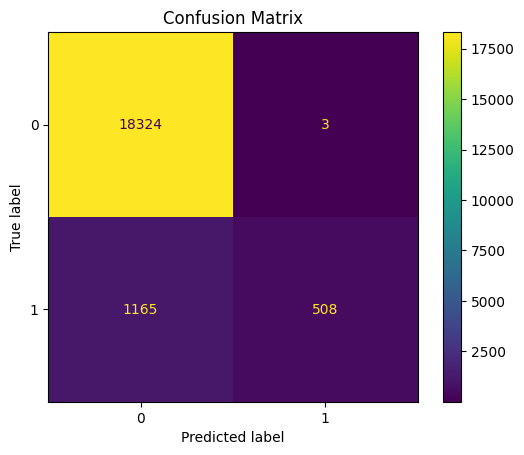

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_lr_test_pred.round())

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

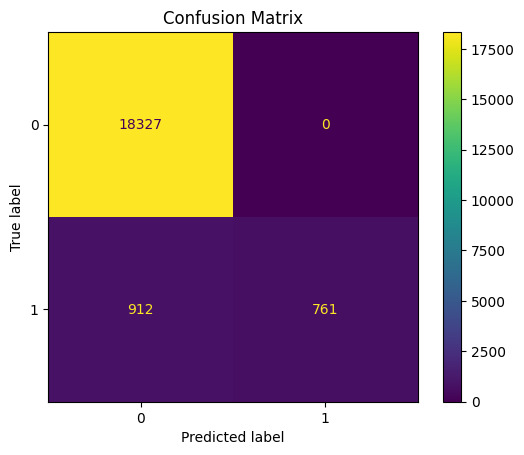

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_rf_test_pred.round())

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

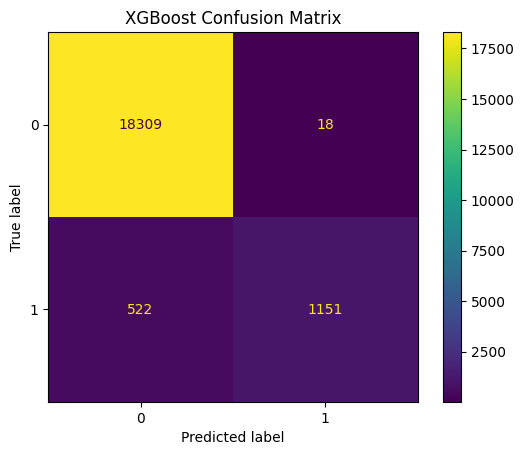

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_xgb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("XGBoost Confusion Matrix")

plt.show()

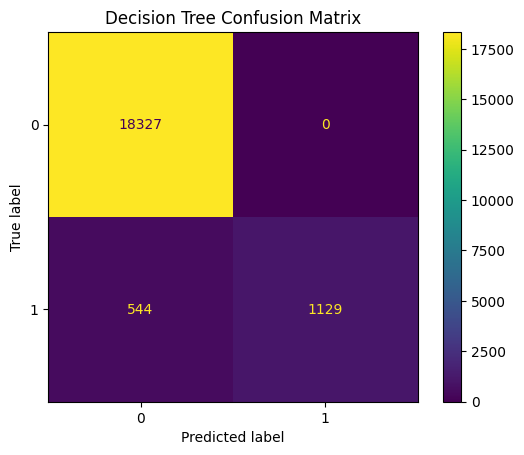

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_dt_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Decision Tree Confusion Matrix")

plt.show()

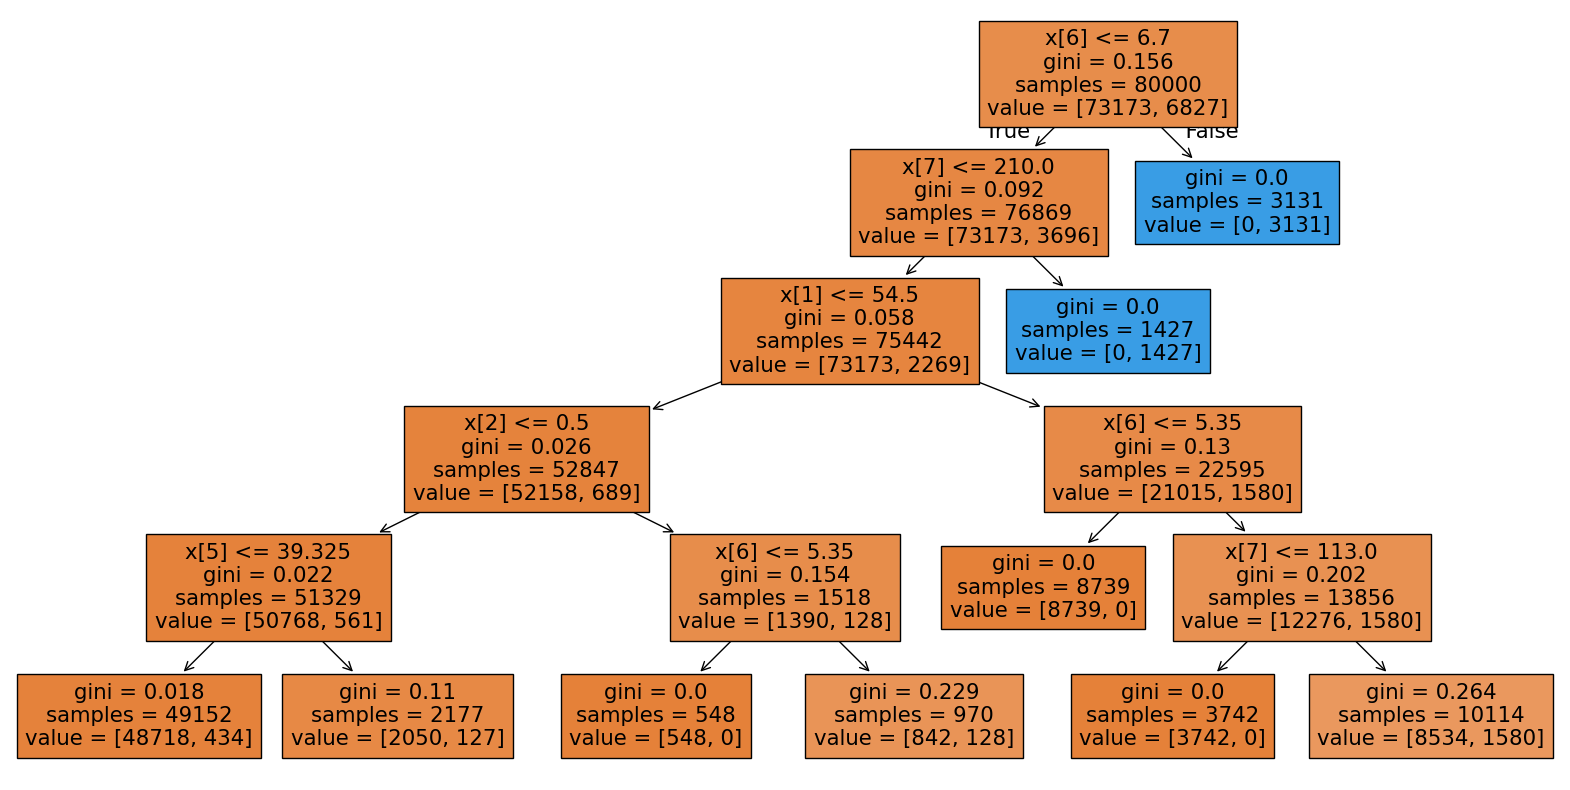

In [45]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

tree.plot_tree(dt,
               filled=True)

plt.show()

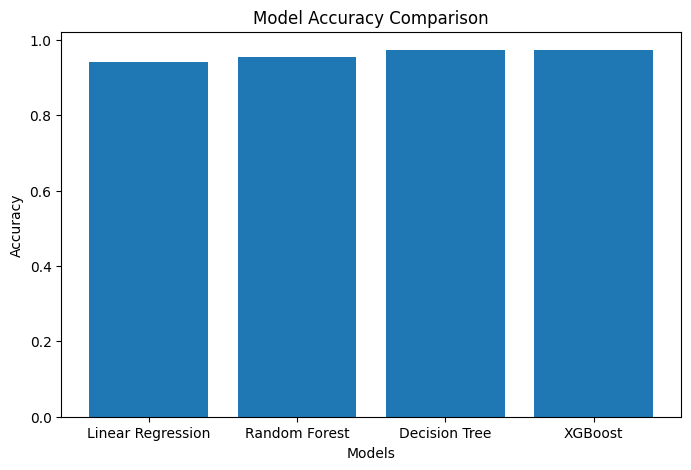

In [46]:
models = [
    'Linear Regression',
    'Random Forest',
    'Decision Tree',
    'XGBoost'
]

accuracy = [
    accuracy_lr,
    accuracy_rf,
    accuracy_dt,
    accuracy_xgb
]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy")

plt.xlabel("Models")

plt.title("Model Accuracy Comparison")

plt.show()